In [18]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

df = pd.read_csv("ratings.csv")

df.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [26]:
df['movie_idx'] = pd.factorize(df['movieId'])[0] #Mandatory for pytorch embdedding
df['user_idx'] = pd.factorize(df['userId'])[0]

num_users = df['userId'].nunique()
num_items = df['movieId'].nunique()

print(num_users, num_items)
df.head()

df.to_csv("hello.csv")

200948 84432


In [29]:
df_movies = pd.read_csv("df_merged_scrapped.csv")

movie_mapping = df[['movieId', 'movie_idx']].drop_duplicates()

df_movies_with_idx = pd.merge(df_movies, movie_mapping, on='movieId', how='inner')

df_movies_with_idx.to_csv("hello.csv")

In [20]:
class TwoTowerNCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim = 64):
        super().__init__()
        
        #Create embedding matrices for users and items (huge matrices from 30M MovieLens)
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

    def forward(self, user_indices, item_indices):

        user_embeds = self.user_embedding(user_indices) #Select x users from the matrice self.user_embedding
        item_embeds = self.item_embedding(item_indices) #Select x movies from the matrice self.user_embedding

        return (user_embeds * item_embeds).sum(dim=1) #Scalar product line by line then horizontal sum

Using mps device
Start training...
Epoch 1/20 - Train MSE: 28.6976 | Val MSE: 6.4876
Epoch 2/20 - Train MSE: 2.7298 | Val MSE: 2.0753
Epoch 3/20 - Train MSE: 1.2225 | Val MSE: 1.5203
Epoch 4/20 - Train MSE: 0.9275 | Val MSE: 1.3133
Epoch 5/20 - Train MSE: 0.8115 | Val MSE: 1.2102
Epoch 6/20 - Train MSE: 0.7539 | Val MSE: 1.1484
Epoch 7/20 - Train MSE: 0.7159 | Val MSE: 1.1052
Epoch 8/20 - Train MSE: 0.6858 | Val MSE: 1.0717
Epoch 9/20 - Train MSE: 0.6601 | Val MSE: 1.0463
Epoch 10/20 - Train MSE: 0.6372 | Val MSE: 1.0255
Epoch 11/20 - Train MSE: 0.6170 | Val MSE: 1.0084
Epoch 12/20 - Train MSE: 0.5984 | Val MSE: 0.9954
Epoch 13/20 - Train MSE: 0.5815 | Val MSE: 0.9839
Epoch 14/20 - Train MSE: 0.5659 | Val MSE: 0.9757
Epoch 15/20 - Train MSE: 0.5515 | Val MSE: 0.9692
Epoch 16/20 - Train MSE: 0.5380 | Val MSE: 0.9647
Epoch 17/20 - Train MSE: 0.5255 | Val MSE: 0.9609
Epoch 18/20 - Train MSE: 0.5137 | Val MSE: 0.9580
Epoch 19/20 - Train MSE: 0.5028 | Val MSE: 0.9566
Epoch 20/20 - Train MSE

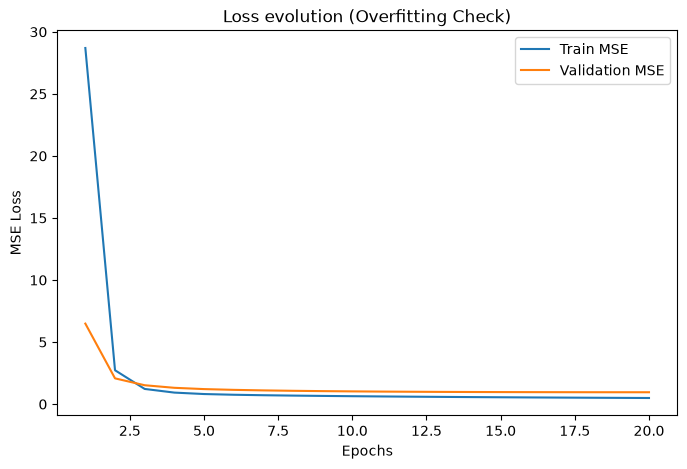

In [25]:
import matplotlib.pyplot as plt

#GPU acceleration (here M2 Pro)
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")


#train-split-test
df_train, df_val = train_test_split(df, test_size = 0.2, random_state = 42)

model = TwoTowerNCF(num_users, num_items, embedding_dim = 64).to(device)
criterion = nn.MSELoss() #MSELoss function
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) #Adam is a classic optimizer to try first


#Preparation of input tensors (data passed batch-by-batch to the model's forward pass)
user_tensor_train = torch.tensor(df_train["user_idx"].values, dtype=torch.long)
item_tensor_train = torch.tensor(df_train["movie_idx"].values, dtype=torch.long)
rating_tensor_train = torch.tensor(df_train["rating"].values, dtype=torch.float32)

user_tensor_val = torch.tensor(df_val["user_idx"].values, dtype=torch.long)
item_tensor_val = torch.tensor(df_val["movie_idx"].values, dtype=torch.long)
rating_tensor_val = torch.tensor(df_val["rating"].values, dtype=torch.float32)

# Training loop
epochs = 20
batch_size = 1024
num_samples_train = len(df_train)
num_samples_val = len(df_val)

train_losses = []
val_losses = []

print("Start training...")

for epoch in range(epochs):

    model.train()
    total_train_loss = 0.0
    
    # Random selection of index (!! Random index but the users and items and notation are not mixed!!)
    permutation_train = torch.randperm(num_samples_train)

    for i in range(0, num_samples_train, batch_size):
        optimizer.zero_grad()  # Del previous gradients from previous batch
        
        # Extract actual batch
        indices = permutation_train[i : i + batch_size]  # Slicing 1024 index
        batch_users = user_tensor_train[indices].to(device)  # Same index of users, items and ratings so they are not mixed
        batch_items = item_tensor_train[indices].to(device)
        batch_ratings = rating_tensor_train[indices].to(device)  # The real rating
        
        # Forward pass
        predictions = model(batch_users, batch_items)  # The prediction rating. batch_users become user_indices and batch_items become item_indices in forward
        
        # Loss calculation
        loss = criterion(predictions, batch_ratings)
        
        # Backward pass and updating weight
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item() * len(indices)  # Mean loss per batch * len of the batch

    train_loss = total_train_loss / num_samples_train

    train_losses.append(train_loss)

    
    # Validation Phase
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        
        for i in range(0, num_samples_val, batch_size):
            # Extract actual batch
            indices = permutation_val[i : i + batch_size]
            batch_users = user_tensor_val[indices].to(device)
            batch_items = item_tensor_val[indices].to(device)
            batch_ratings = rating_tensor_val[indices].to(device)
            
            # Forward pass
            predictions = model(batch_users, batch_items)
            
            #No backward here ! Validation 
            
            # Loss calculation
            loss = criterion(predictions, batch_ratings)
            
            total_val_loss += loss.item() * len(indices)

    val_loss = total_val_loss / num_samples_val

    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

#----NB : I tried for 40 epochs, the first before overfitting is 20 epochs (Val MSE stop decreasing)-----

# Save weighted model for Streamlit usage
movie_embeddings = model.item_embedding.weight.detach().cpu().numpy()

# Saving
np.save("movie_embeddings.npy", movie_embeddings)
print("End of training and save!")

#Check overfitting
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), train_losses, label = "Train MSE")
plt.plot(range(1, epochs + 1), val_losses, label="Validation MSE")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss evolution (Overfitting Check)")
plt.legend()
plt.show()